# Importing and Setting Up Data

In [76]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [77]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV

In [78]:
# Removing Truncation of rows and columns in the output

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [79]:
# Loading the datasets
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

In [80]:
# Creating a copy of the training dataset so we can perform data cleaning and feature engineering without affecting the original dataset
train_df = train.copy()

In [81]:
# Basic Information about the dataset

print("Training Dataset Shape:", train_df.shape, "\n")

print("\n ---- Training Dataset Info ---- \n")
train_df.info()

print("\n ---- Training Dataset Null Values ---- \n")
print(train_df.isnull().sum().to_string())

print("\n ---- Training Dataset Description ---- \n")
train_df.describe()

Training Dataset Shape: (891, 12) 


 ---- Training Dataset Info ---- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

 ---- Training Dataset Null Values ---- 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp          

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# EDA

<Axes: xlabel='Survived', ylabel='count'>

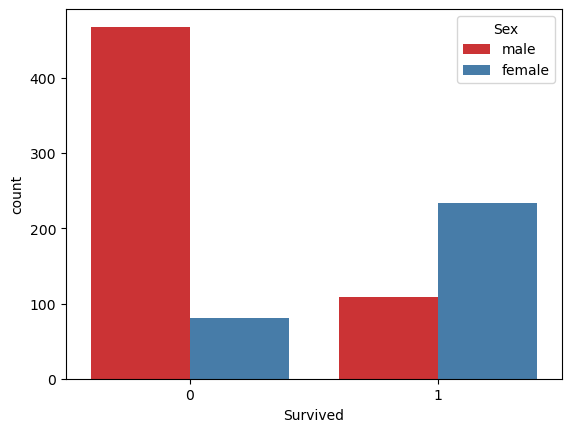

In [82]:
# Checking distribution of the target variable 'Survived' in the training dataset
sns.countplot(x='Survived', data=train_df, hue='Sex', palette='Set1')

- Males have very less chances of survival
- Females have most chances of survival

<Axes: xlabel='Pclass', ylabel='count'>

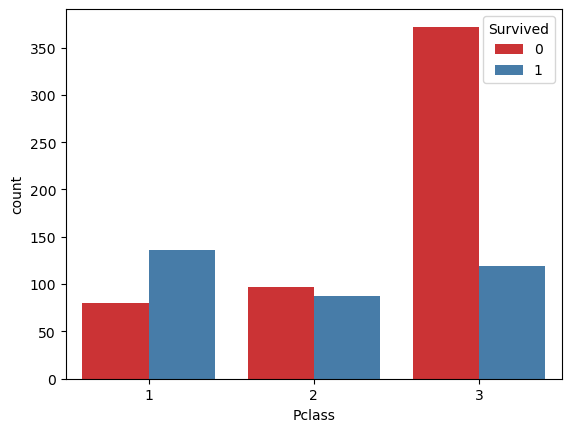

In [83]:
sns.countplot(x="Pclass", data=train_df, hue="Survived", palette="Set1")

- Most Deaths are in 3rd Pclass
- Least Deaths in 1st Pclass

There's a linear relationship between Survived and Pclass. As Pclass is higher (in terms of status) Survival chances increases

<Axes: xlabel='Age', ylabel='Count'>

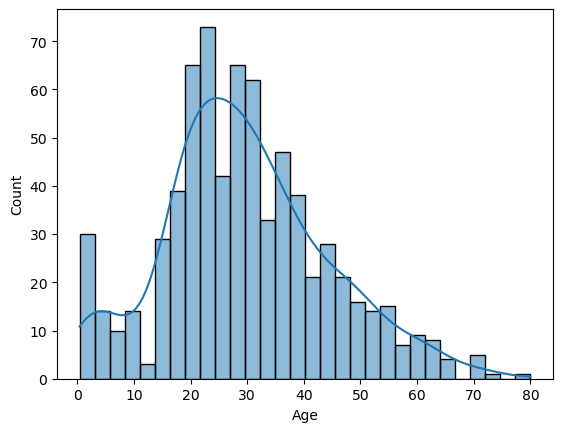

In [84]:
# Distribution of Age in the training dataset
sns.histplot(data=train_df, x='Age', bins=30, kde=True)

- Age in itself is Right Skewed
- Most Ages are between 20:35

<Axes: xlabel='Survived', ylabel='Age'>

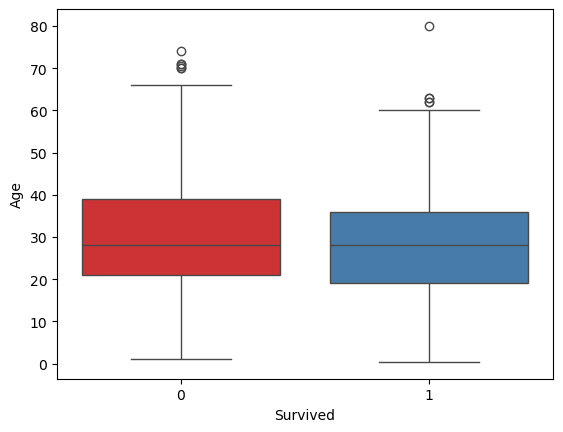

In [85]:
sns.boxplot(x='Survived', y='Age', data=train_df, palette='Set1')

- Higher Aged people have less chances of survival but not too much of difference

<Axes: xlabel='Pclass', ylabel='Age'>

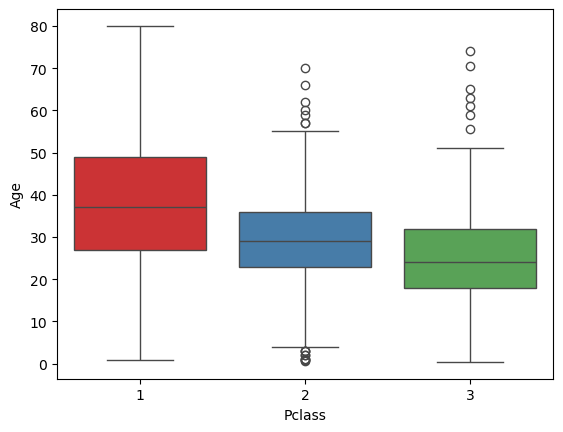

In [86]:
sns.boxplot(x='Pclass', y='Age', data=train_df, palette='Set1')

- As Age increases Pclass Increases (in status sybmols). Outliers in Pclass 2 and 3

<Axes: xlabel='Age', ylabel='Fare'>

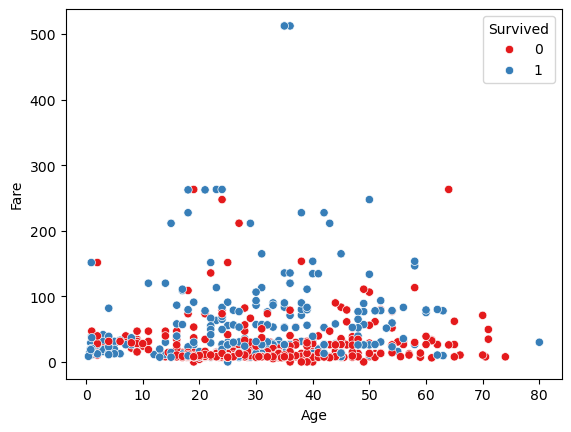

In [87]:
sns.scatterplot(x='Age', y='Fare', data=train_df, hue='Survived', palette='Set1')

- Higher Fare Means Higher chance of Survival, has outliers
- Age and Fare have no clear relationship

In [88]:
corr_matrix = train_df.select_dtypes(include=['int64', 'float64']).corr()

<Axes: >

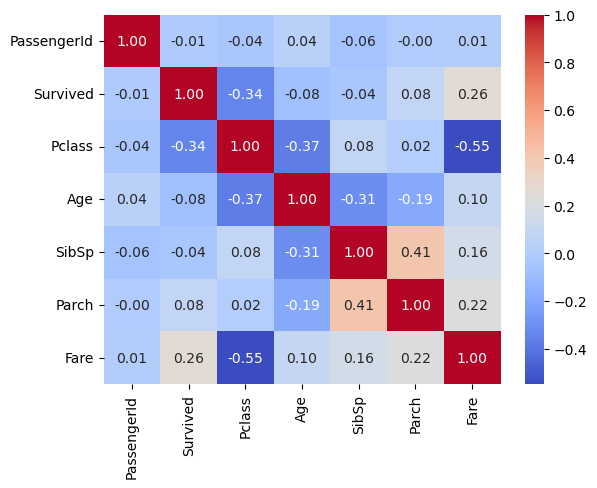

In [89]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

- Parch and Sibsp are 0.41 correlated
- Fare and Pclass have -0.55 correlation

<Axes: xlabel='Pclass', ylabel='Fare'>

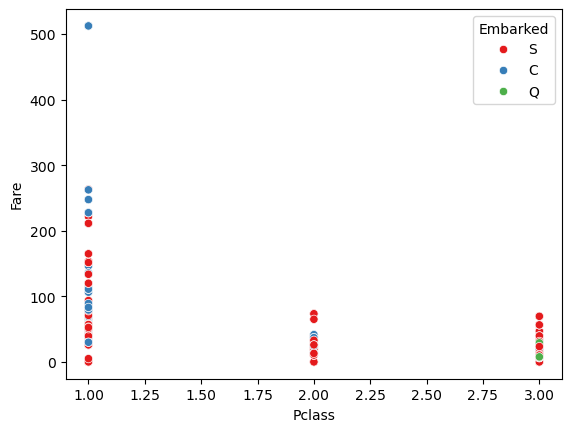

In [90]:
sns.scatterplot(x='Pclass', y='Fare', data=train_df, hue='Embarked', palette='Set1')

- C = Cherbourg: Passengers who boarded here had a noticeably higher survival rate, as this port attracted many wealthy, first-class passengers who paid higher fares.

- Q = Queenstown: Primarily a stop for lower-class (3rd class) passengers.

- S = Southampton: The primary departure point where most of the passengers (over 70%) boarded. Many of the third-class and crew members boarded here.

In [91]:
train_df["Ticket"].head(10)

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
5              330877
6               17463
7              349909
8              347742
9              237736
Name: Ticket, dtype: object

- We'll maybe drop Ticket later because its highly unqiue and filled with noise. If the Model Overfits then definately we remove this

In [92]:
print("Percentage of missing values in the 'Cabin' column:")
print(train_df["Cabin"].isnull().sum() / train_df.shape[0] * 100)
print("\n")

print("Unique values in the 'Cabin' column:")
print(train_df["Cabin"].unique())

Percentage of missing values in the 'Cabin' column:
77.10437710437711


Unique values in the 'Cabin' column:
[nan 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33'
 'B30' 'C52' 'B28' 'C83' 'F33' 'F G73' 'E31' 'A5' 'D10 D12' 'D26' 'C110'
 'B58 B60' 'E101' 'F E69' 'D47' 'B86' 'F2' 'C2' 'E33' 'B19' 'A7' 'C49'
 'F4' 'A32' 'B4' 'B80' 'A31' 'D36' 'D15' 'C93' 'C78' 'D35' 'C87' 'B77'
 'E67' 'B94' 'C125' 'C99' 'C118' 'D7' 'A19' 'B49' 'D' 'C22 C26' 'C106'
 'C65' 'E36' 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'B18' 'C124' 'C91'
 'E40' 'T' 'C128' 'D37' 'B35' 'E50' 'C82' 'B96 B98' 'E10' 'E44' 'A34'
 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'A14' 'B37' 'C30' 'D20' 'B79'
 'E25' 'D46' 'B73' 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'C101' 'C68'
 'A10' 'E68' 'B41' 'A20' 'D19' 'D50' 'D9' 'A23' 'B50' 'A26' 'D48' 'E58'
 'C126' 'B71' 'B51 B53 B55' 'D49' 'B5' 'B20' 'F G63' 'C62 C64' 'E24' 'C90'
 'C45' 'E8' 'B101' 'D45' 'C46' 'D30' 'E121' 'D11' 'E77' 'F38' 'B3' 'D6'
 'B82 B84' 'D17' 'A36

We'll Decide Later if we wanna drop the column or create a binary flag and extract deck. 

# Data Cleaning

In [93]:
total_duplicates = train_df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 0


In [94]:
missing_table = {}
for column in train_df.columns:
    missing_count = train_df[column].isnull().sum()
    missing_percentage = (missing_count / train_df.shape[0]) * 100
    missing_table[column] = {"Missing Count": missing_count, "Missing Percentage": missing_percentage}

print("Missing Values Summary:")
for column, values in missing_table.items():
    print(f"{column}: {values['Missing Count']}, ({values['Missing Percentage']:.2f}%)")

Missing Values Summary:
PassengerId: 0, (0.00%)
Survived: 0, (0.00%)
Pclass: 0, (0.00%)
Name: 0, (0.00%)
Sex: 0, (0.00%)
Age: 177, (19.87%)
SibSp: 0, (0.00%)
Parch: 0, (0.00%)
Ticket: 0, (0.00%)
Fare: 0, (0.00%)
Cabin: 687, (77.10%)
Embarked: 2, (0.22%)


- Age has 20% missing data
- Cabin has 77% missing data
- Embarked has just 2 missing data points

In [95]:
# Filling missing values in the 'Embarked' column with the mode (most frequent value)
embarked_mode = train_df['Embarked'].mode()[0]
train_df['Embarked'].fillna(embarked_mode, inplace=True)

if train_df["Embarked"].isnull().sum() == 0:
    print("Missing values imputed successfully")
else:
    print("There was some error!")

Missing values imputed successfully


In [96]:
# Filling Missing values in Age
train_df["Age"].fillna(train_df["Age"].median(), inplace=True)

if train_df["Age"].isnull().sum() == 0:
    print("Missing values imputed successfully")
else:
    print("There was some error!")

Missing values imputed successfully


In [97]:
# Dropping uneccesary columns
train_df.drop(columns=['Cabin', 'Name', 'PassengerId', 'Ticket'], inplace=True)


print('Missing values after handling:')
print(train_df.isnull().sum())

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [98]:
# Encode Sex: male=1, female=0
train_df['Sex'] = train_df['Sex'].map({'male': 1, 'female': 0})

# One-hot encode Embarked (3 categories: S, C, Q) with drop_first to avoid multicollinearity
train_df = pd.get_dummies(train_df, columns=['Embarked'], drop_first=True)

print('Columns after encoding:', train_df.columns.tolist())
train_df.head(3)

Columns after encoding: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True


In [99]:
# Combining Sibsp and Parch
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1

# Adding IsAlone Binary Flag
train_df["IsAlone"] = (train_df["FamilySize"] == 1).astype(int)




# Model Building

In [100]:
X = train_df.drop(columns=["Survived"])
y = train_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 712
Testing  samples : 179
Features         : 10


In [101]:
# Creating a function to evaluate models

def evaluate_model(model, X_test, y_test):
    """
    Evaluates a classification model with explanations.
    """

    model_name = model.__class__.__name__
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("=" * 80)
    print(f"{model_name.upper()} EVALUATION")
    print("=" * 80)

    print("\n1. ACCURACY")
    print("-" * 80)
    print("Meaning: Percentage of predictions the model got correct.")
    print(f"Accuracy Score: {acc:.4f}")

    print("\n2. PRECISION")
    print("-" * 80)
    print("Meaning: Of everything predicted as Survived, how many actually survived?")
    print(f"Precision Score: {prec:.4f}")

    print("\n3. RECALL")
    print("-" * 80)
    print("Meaning: Of everyone who actually survived, how many did the model correctly identify?")
    print(f"Recall Score: {rec:.4f}")

    print("\n4. F1 SCORE")
    print("-" * 80)
    print("Meaning: Balance between Precision and Recall.")
    print(f"F1 Score: {f1:.4f}")

    print("\n5. CONFUSION MATRIX")
    print("-" * 80)
    print("Meaning: Shows where the model predicted correctly and where it made mistakes.\n")

    cm_df = pd.DataFrame(
        cm,
        index=["Actual: Didn't Survive", "Actual: Survived"],
        columns=["Predicted: Didn't Survive", "Predicted: Survived"]
    )

    print(cm_df)

    print("\nBreakdown")
    print(f"True Negative  (TN): {tn}")
    print(f"False Positive (FP): {fp}")
    print(f"False Negative (FN): {fn}")
    print(f"True Positive  (TP): {tp}")

    print("\nInterpretation")
    print("TN → Correctly predicted 'Didn't Survive'")
    print("FP → Predicted 'Survived' but actually 'Didn't Survive'")
    print("FN → Predicted 'Didn't Survive' but actually 'Survived'")
    print("TP → Correctly predicted 'Survived'")

    print("\n6. CLASSIFICATION REPORT")
    print("-" * 80)
    print("Meaning: Complete summary of Precision, Recall, F1-score and Support for each class.\n")

    print(classification_report(y_test, y_pred))

    print("=" * 80)

In [102]:
lr = LogisticRegression(max_iter = 250, random_state=42)
lr.fit(X_train, y_train)

evaluate_model(lr, X_test, y_test)

LOGISTICREGRESSION EVALUATION

1. ACCURACY
--------------------------------------------------------------------------------
Meaning: Percentage of predictions the model got correct.
Accuracy Score: 0.7989

2. PRECISION
--------------------------------------------------------------------------------
Meaning: Of everything predicted as Survived, how many actually survived?
Precision Score: 0.7714

3. RECALL
--------------------------------------------------------------------------------
Meaning: Of everyone who actually survived, how many did the model correctly identify?
Recall Score: 0.7297

4. F1 SCORE
--------------------------------------------------------------------------------
Meaning: Balance between Precision and Recall.
F1 Score: 0.7500

5. CONFUSION MATRIX
--------------------------------------------------------------------------------
Meaning: Shows where the model predicted correctly and where it made mistakes.

                        Predicted: Didn't Survive  Predicted: 

In [103]:
svm = SVC()
svm.fit(X_train, y_train)

evaluate_model(svm, X_test, y_test)

SVC EVALUATION

1. ACCURACY
--------------------------------------------------------------------------------
Meaning: Percentage of predictions the model got correct.
Accuracy Score: 0.6592

2. PRECISION
--------------------------------------------------------------------------------
Meaning: Of everything predicted as Survived, how many actually survived?
Precision Score: 0.7600

3. RECALL
--------------------------------------------------------------------------------
Meaning: Of everyone who actually survived, how many did the model correctly identify?
Recall Score: 0.2568

4. F1 SCORE
--------------------------------------------------------------------------------
Meaning: Balance between Precision and Recall.
F1 Score: 0.3838

5. CONFUSION MATRIX
--------------------------------------------------------------------------------
Meaning: Shows where the model predicted correctly and where it made mistakes.

                        Predicted: Didn't Survive  Predicted: Survived
Actual

- For now logistic regression is the best

In [104]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test)

RANDOMFORESTCLASSIFIER EVALUATION

1. ACCURACY
--------------------------------------------------------------------------------
Meaning: Percentage of predictions the model got correct.
Accuracy Score: 0.8324

2. PRECISION
--------------------------------------------------------------------------------
Meaning: Of everything predicted as Survived, how many actually survived?
Precision Score: 0.8056

3. RECALL
--------------------------------------------------------------------------------
Meaning: Of everyone who actually survived, how many did the model correctly identify?
Recall Score: 0.7838

4. F1 SCORE
--------------------------------------------------------------------------------
Meaning: Balance between Precision and Recall.
F1 Score: 0.7945

5. CONFUSION MATRIX
--------------------------------------------------------------------------------
Meaning: Shows where the model predicted correctly and where it made mistakes.

                        Predicted: Didn't Survive  Predict

- Random Forest Classifier is in lead now

In [105]:
xgboost = XGBClassifier()
xgboost.fit(X_train, y_train)

evaluate_model(xgboost, X_test, y_test)

XGBCLASSIFIER EVALUATION

1. ACCURACY
--------------------------------------------------------------------------------
Meaning: Percentage of predictions the model got correct.
Accuracy Score: 0.7989

2. PRECISION
--------------------------------------------------------------------------------
Meaning: Of everything predicted as Survived, how many actually survived?
Precision Score: 0.7639

3. RECALL
--------------------------------------------------------------------------------
Meaning: Of everyone who actually survived, how many did the model correctly identify?
Recall Score: 0.7432

4. F1 SCORE
--------------------------------------------------------------------------------
Meaning: Balance between Precision and Recall.
F1 Score: 0.7534

5. CONFUSION MATRIX
--------------------------------------------------------------------------------
Meaning: Shows where the model predicted correctly and where it made mistakes.

                        Predicted: Didn't Survive  Predicted: Survi

- Random Forest Classifier is current best baseline

# Improving Models

In [106]:
def check_overfitting(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("=" * 50)
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)
    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Testing Accuracy  : {test_acc:.4f}")
    print(f"Difference        : {train_acc - test_acc:.4f}")

    if train_acc - test_acc > 0.05:
        print("\n⚠️ Possible Overfitting")
    elif test_acc > train_acc:
        print("\n⚠️ Test accuracy is higher than training accuracy.")
        print("This can happen due to randomness or a small dataset.")
    else:
        print("\n✅ No significant overfitting detected.")

check_overfitting(rf, X_train, y_train, X_test, y_test)

Model: RandomForestClassifier
Training Accuracy : 0.9789
Testing Accuracy  : 0.8324
Difference        : 0.1465

⚠️ Possible Overfitting


In [107]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base model
rf = RandomForestClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}

Best Cross Validation Accuracy:
0.8384418398502905


In [108]:
evaluate_model(best_rf, X_test, y_test)

check_overfitting(best_rf, X_train, y_train, X_test, y_test)

RANDOMFORESTCLASSIFIER EVALUATION

1. ACCURACY
--------------------------------------------------------------------------------
Meaning: Percentage of predictions the model got correct.
Accuracy Score: 0.8101

2. PRECISION
--------------------------------------------------------------------------------
Meaning: Of everything predicted as Survived, how many actually survived?
Precision Score: 0.8226

3. RECALL
--------------------------------------------------------------------------------
Meaning: Of everyone who actually survived, how many did the model correctly identify?
Recall Score: 0.6892

4. F1 SCORE
--------------------------------------------------------------------------------
Meaning: Balance between Precision and Recall.
F1 Score: 0.7500

5. CONFUSION MATRIX
--------------------------------------------------------------------------------
Meaning: Shows where the model predicted correctly and where it made mistakes.

                        Predicted: Didn't Survive  Predict

- Now we have to work on improving testing accuracy

In [109]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

      Feature  Importance
1         Sex    0.454956
5        Fare    0.156797
0      Pclass    0.135453
2         Age    0.108572
8  FamilySize    0.058144
3       SibSp    0.027427
7  Embarked_S    0.019918
4       Parch    0.019865
9     IsAlone    0.012611
6  Embarked_Q    0.006257


# Submitting

In [116]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
test_predictions = best_rf.predict(test)